# The public-intermediation problem

**Reader question.** Why can a government have a useful portfolio role even when
capital markets price the available claim correctly?

**Answer in brief.** The government is not assumed to spot a mispriced asset. Markets
price payoffs using the marginal value of consumption to international investors,
whereas a worker-oriented government values resources using their contribution to
worker consumption. If automation states affect those groups differently, the two
state-price kernels differ. A public claim can then move resources toward states that
are expensive in the government's fiscal valuation even when its market price is
exactly correct.

This is a **conditional analytical characterization** on the smooth-interior Brownian
branch. The numerical example below is deliberately illustrative, not calibrated.

## Model and comparison

The comparison fixes the technology, shock law, world prices, ownership, commitment
convention, and inherited augmented state $(S_0,M_0)$. Workers cannot trade the
external risky claim directly. The government chooses worker consumption, tax
adjustment, a safe position, and—when available—a position in that claim. Domestic
capital remains privately owned, and representative-worker welfare is the objective.

For a payoff $X_{t+1}$, write its market and fiscal values as

$$
P_t=\mathbb E_t[m_I X_{t+1}],
\qquad
G_t=\mathbb E_t[m_G X_{t+1}],
\qquad
\Theta=\frac{m_G}{m_I}.
$$

$m_I$ is the international investor's stochastic discount factor. $m_G$ is the
government's fiscal valuation kernel: it incorporates how an extra unit of public
resources ultimately changes worker consumption. A difference between $P_t$ and
$G_t$ is therefore a difference in incidence and marginal value, not evidence of
market mispricing.

## A two-state valuation illustration

The next cell holds probabilities and the market pricing kernel fixed, then tilts the
fiscal kernel toward a state in which workers are relatively exposed. The claim pays
more in that state. The values are arbitrary units chosen only to make the mechanism
visible; they are not an output of the paper's calibrated or solved models.

| State | Probability | Market SDF | Fiscal / market SDF | Claim payoff |
|---|---:|---:|---:|---:|
| worker downside | 0.50 | 1.10 | 1.50 | 1.40 |
| shared upside | 0.50 | 0.90 | 0.70 | 0.20 |

**Illustrative market value:** 0.860

**Illustrative fiscal value:** 1.218

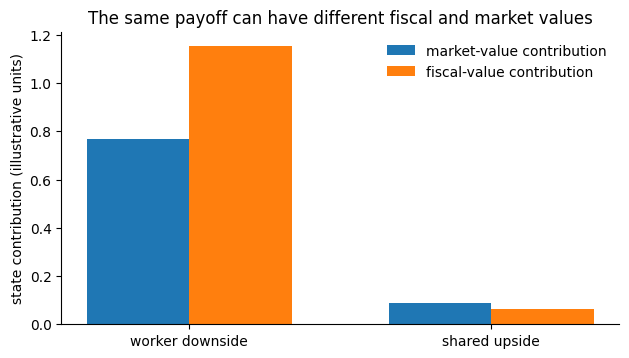

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

states = ["worker downside", "shared upside"]
probability = np.array([0.5, 0.5])
market_sdf = np.array([1.10, 0.90])
fiscal_to_market_ratio = np.array([1.50, 0.70])
fiscal_sdf = market_sdf * fiscal_to_market_ratio
claim_payoff = np.array([1.40, 0.20])

market_contribution = probability * market_sdf * claim_payoff
fiscal_contribution = probability * fiscal_sdf * claim_payoff
market_value = market_contribution.sum()
fiscal_value = fiscal_contribution.sum()

lines = [
    "| State | Probability | Market SDF | Fiscal / market SDF | Claim payoff |",
    "|---|---:|---:|---:|---:|",
]
for label, p, m_i, ratio, payoff in zip(
    states, probability, market_sdf, fiscal_to_market_ratio, claim_payoff
):
    lines.append(f"| {label} | {p:.2f} | {m_i:.2f} | {ratio:.2f} | {payoff:.2f} |")
lines.extend(
    [
        "",
        f"**Illustrative market value:** {market_value:.3f}",
        "",
        f"**Illustrative fiscal value:** {fiscal_value:.3f}",
    ]
)
display(Markdown("\n".join(lines)))

fig, ax = plt.subplots(figsize=(7.2, 3.8))
x = np.arange(len(states))
width = 0.34
ax.bar(x - width / 2, market_contribution, width, label="market-value contribution")
ax.bar(x + width / 2, fiscal_contribution, width, label="fiscal-value contribution")
ax.set_xticks(x, states)
ax.set_ylabel("state contribution (illustrative units)")
ax.set_title("The same payoff can have different fiscal and market values")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

## What each instrument does

The three instruments are not interchangeable labels for “more fiscal capacity.”

| Instrument | Margin it changes | What it cannot do by itself |
|---|---|---|
| Safe position | Moves resources across dates at the safe rate | Reallocate resources across simultaneous shock directions |
| Risky public claim | Moves resources along its payoff vector | Hedge the component orthogonal to that payoff span |
| Tax policy | Redistributes current factor income and changes accumulation incentives | Create an inherited jump payoff at the instant of an inaccessible shock |

At a smooth interior portfolio optimum, the fiscal-versus-market valuation residual is
orthogonal to the available public payoff span. It need not vanish state by state. That
distinction is the bridge to the next notebook.

## Economic interpretation

The portfolio motive is strongest when a traded payoff arrives in states where worker
consumption is relatively scarce but investor consumption is not. The opposing force
is the asset's market cost and any fiscal or portfolio constraint. Correct market
pricing therefore disciplines the government without eliminating its insurance role.

The example above establishes no optimal holding, welfare magnitude, tax response, or
real-world policy recommendation. Formal Brownian claims R07 and R20 remain
publication-blocked at their current assurance stage; this notebook explains their
conditional mechanism rather than promoting them.

## Reproduce and trace

- Implementation map: [`Nathan-Barnard/tai-public-finance`](https://github.com/Nathan-Barnard/tai-public-finance/tree/971cab12986bce99c23a291fd62a5cde66ffa01a)
- Public container commit: `971cab12986bce99c23a291fd62a5cde66ffa01a`
- Research objects: Brownian public-portfolio characterizations R07 and R20
- Evidence status: conditional analytical characterization; illustration only
- Notebook environment: repository `requirements-dev.txt`

No upstream solver is called here because no numerical optimum is claimed. Re-run the
notebook from the repository root with `jupyter nbconvert --to notebook --execute --inplace notebooks/01_public_intermediation_problem.ipynb`.